In [14]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
df = pd.read_csv(r"C:\Users\ragha\Downloads\global_supply_chain_risk_2026.csv")
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [ ]:
df.columns = df.columns.str.strip()
weather_map = {'Hurricane': 5, 'Storm': 4, 'Rain': 2, 'Fog': 2, 'Clear': 1}
df['Weather_Severity'] = df['Weather_Condition'].map(weather_map).fillna(1)
df['Stress_Index'] = df['Geopolitical_Risk_Score'] * df['Weather_Severity']
print("Dataset Ready for Analysis. Shape:", df.shape)
print(df[['Shipment_ID', 'Stress_Index']].head())

Dataset Ready for Analysis. Shape: (5000, 16)
  Shipment_ID  Stress_Index
0    SC-10000          25.0
1    SC-10001          30.0
2    SC-10002          11.2
3    SC-10003           4.0
4    SC-10004           3.8


In [ ]:
features = [
    'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 
    'Geopolitical_Risk_Score', 'Weather_Severity', 'Stress_Index',
    'Transport_Mode', 'Product_Category'
]
X = df[features]
y = df['Lead_Time_Days']
categorical_features = ['Transport_Mode', 'Product_Category']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough')
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} days")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

MAE: 1.02 days
R2 Score: 0.9974


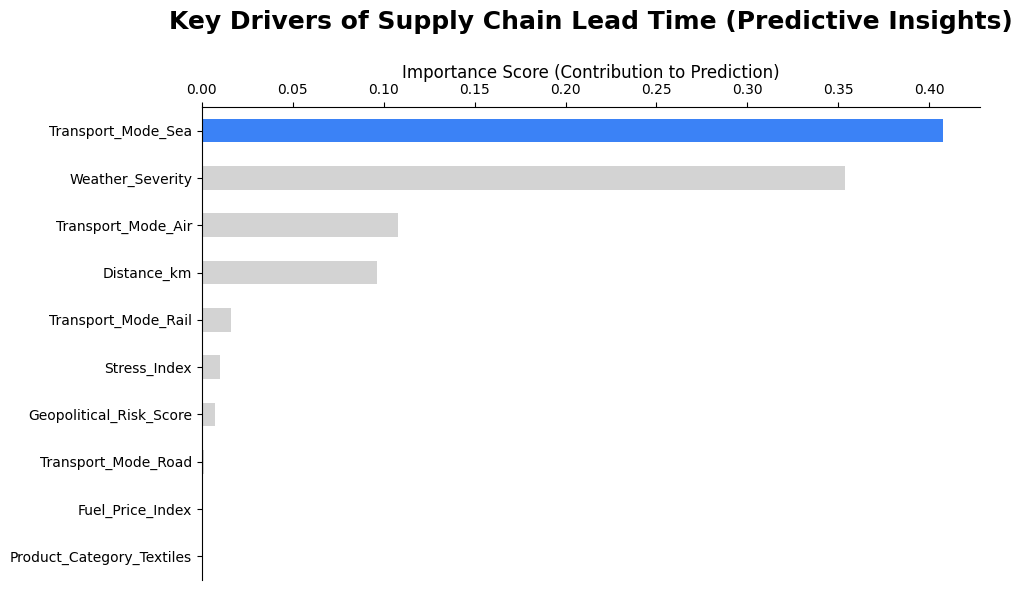

In [40]:
highlight_color = 'blue'
neutral_color='lightgray'
ohe_cols = model_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_features)
numeric_cols = [f for f in features if f not in categorical_features]
all_features = list(ohe_cols) + numeric_cols
importances = model_pipeline.named_steps['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)
plt.figure(figsize=(10, 6), facecolor='white')
ax=plt.gca()
colors=['lightgray']*9+['#3b82f6']
feat_imp.tail(10).plot(kind='barh', color=colors)
plt.title("Key Drivers of Supply Chain Lead Time (Predictive Insights)", fontsize=18, pad=25, color='black', fontweight='bold', fontfamily='DejaVu Sans')
plt.xlabel("Importance Score (Contribution to Prediction)", fontsize=12)
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.grid(False)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()

In [41]:
def run_supply_chain_simulation(model, original_data, risk_increase_pct):
    sim_data = original_data.copy()
    sim_data['Geopolitical_Risk_Score'] = sim_data['Geopolitical_Risk_Score'] * (1 + risk_increase_pct/100)
    sim_data['Stress_Index'] = sim_data['Geopolitical_Risk_Score'] * sim_data['Weather_Severity']
    original_preds = model.predict(original_data)
    sim_preds = model.predict(sim_data)
    avg_delay_increase = sim_preds.mean() - original_preds.mean()
    max_delay_impact = sim_preds.max() - original_preds.max()
    
    print(f"--- 2026 STRATEGIC SIMULATION REPORT ---")
    print(f"Scenario: {risk_increase_pct}% Surge in Global Geopolitical Risk")
    print(f"Average Systemic Delay: +{avg_delay_increase:.2f} Days")
    print(f"Worst-Case Route Impact: +{max_delay_impact:.2f} Days")
    print(f"-----------------------------------------")
    
    return sim_preds
new_lead_times = run_supply_chain_simulation(model_pipeline, X_test, 25)

--- 2026 STRATEGIC SIMULATION REPORT ---
Scenario: 25% Surge in Global Geopolitical Risk
Average Systemic Delay: +0.90 Days
Worst-Case Route Impact: +12.19 Days
-----------------------------------------
